findfont: Failed to find font weight bold, now using 400.


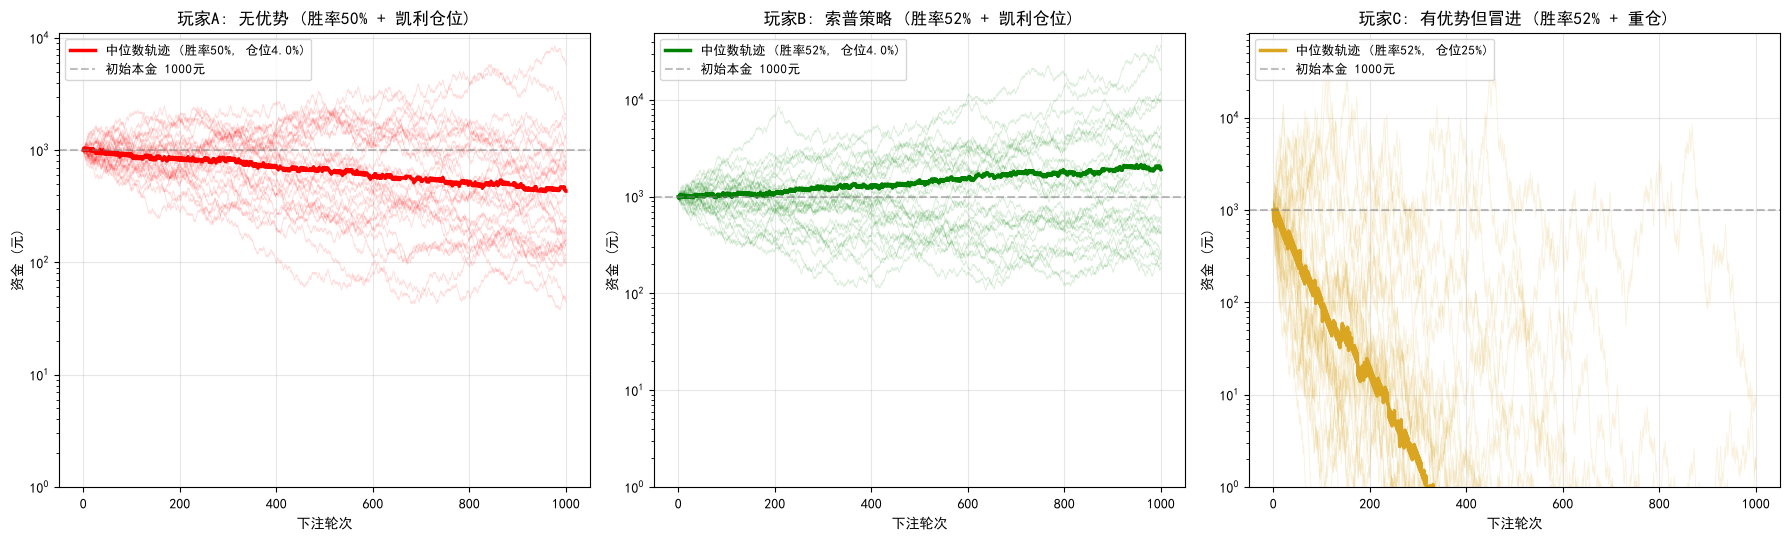

凯利公式计算: 最优下注比例 f* = 4.00% (胜率52%, 赔率1:1)

  【玩家A (无优势)】
    中位数终点资金: 432元
    盈利概率: 23.5%
    最好情况: 43,026元 | 最差情况: 13.27元

  【玩家B (索普策略)】
    中位数终点资金: 1,897元
    盈利概率: 70.5%
    最好情况: 50,495元 | 最差情况: 90.58元

  【玩家C (有优势但冒进)】
    中位数终点资金: 0元
    盈利概率: 0.0%
    最好情况: 916元 | 最差情况: 0.01元

  → 没有概率优势，凯利公式也救不了你（玩家A）
  → 仅仅2%的胜率优势 + 科学仓位管理 = 长期稳定复利（玩家B）
  → 有优势但仓位过重，反而可能亏光（玩家C）
  → 这就是索普的核心发现：概率优势 × 仓位管理 = 量化盈利的底层公式


In [1]:
# ========== 实验二：索普——概率优势 + 凯利仓位 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 坐标轴负号正常显示

np.random.seed(2026)  # 固定随机种子，结果可复现

n_rounds = 1000             # 每位玩家模拟下注 1000 轮
n_simulations = 200         # 每种策略重复 200 次（看分布）
initial_capital = 1000      # 初始本金 1000 元

win_prob_no_edge = 0.50     # 玩家A：无优势，胜率 50%
win_prob_edge = 0.52        # 玩家B/C：有 2% 概率优势
payout_ratio = 1.0          # 赔率 1:1（赢一倍赌注，输一倍赌注）

# 凯利公式: f* = (bp - q) / b  → 最优下注占本金比例
kelly_fraction = (payout_ratio * win_prob_edge - (1 - win_prob_edge)) / payout_ratio  # 凯利公式最优下注比例
aggressive_fraction = 0.25  # 玩家C：有优势但每次下注 25%（太激进）


def simulate_player(win_prob, bet_fraction, n_sims=n_simulations):  # 定义模拟下注函数
    """模拟多人在 n_rounds 轮里的资金曲线。"""  # 字典字段
    all_curves = []              # 存放每次实验的资金曲线
    for _ in range(n_sims):              # 外层：重复很多次实验
        capital = initial_capital        # 本轮起始资金
        curve = [capital]              # 记录每轮后的资金
        for _ in range(n_rounds):      # 内层：一轮轮下注
            bet = capital * bet_fraction   # 本轮下注额 = 本金 × 比例
            if np.random.random() < win_prob:  # 随机数小于胜率 → 赢
                capital += bet * payout_ratio  # 赢：拿回赌注并赚一倍
            else:                              # 否则 → 输
                capital -= bet                 # 输：输掉本轮赌注
            capital = max(capital, 0.01)       # 防止资金变成负数
            curve.append(capital)  # 执行本行代码
        all_curves.append(curve)  # 执行本行代码
    return np.array(all_curves)        # 转成二维数组：行=实验，列=轮次


curves_A = simulate_player(win_prob_no_edge, kelly_fraction)       # 无优势 + 凯利
curves_B = simulate_player(win_prob_edge, kelly_fraction)          # 有优势 + 凯利
curves_C = simulate_player(win_prob_edge, aggressive_fraction)     # 有优势 + 重仓

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))  # 三个玩家各一张子图

configs = [  # 三个子图的配置
    (curves_A, '玩家A: 无优势 (胜率50% + 凯利仓位)', 'red', f'胜率50%, 仓位{kelly_fraction*100:.1f}%'),  # 执行本行代码
    (curves_B, '玩家B: 索普策略 (胜率52% + 凯利仓位)', 'green', f'胜率52%, 仓位{kelly_fraction*100:.1f}%'),  # 执行本行代码
    (curves_C, '玩家C: 有优势但冒进 (胜率52% + 重仓)', 'goldenrod', f'胜率52%, 仓位25%'),  # 执行本行代码
]                                              # 数组拼接结束

for ax, (curves, title, color, label) in zip(axes, configs):  # 为每个玩家画子图
    for i in range(min(30, n_simulations)):   # 只画前30条细线，避免太乱
        ax.plot(curves[i], alpha=0.15, linewidth=0.6, color=color)  # 在子图上画折线
    median_curve = np.median(curves, axis=0)  # 200次实验的中位数轨迹
    ax.plot(median_curve, color=color, linewidth=2.5, label=f'中位数轨迹 ({label})')  # 在子图上画折线
    ax.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label=f'初始本金 {initial_capital}元')  # 画水平参考线
    ax.set_title(title, fontsize=12, fontweight='bold')  # 设置子图标题
    ax.set_xlabel('下注轮次')  # 设置子图横轴
    ax.set_ylabel('资金 (元)')  # 设置子图纵轴
    ax.legend(fontsize=9, loc='upper left')  # 显示图例
    ax.grid(True, alpha=0.3)  # 显示网格
    ax.set_yscale('log')      # 纵轴用对数刻度，差距大时更好看
    ax.set_ylim(1, None)  # 设置纵轴范围

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

print("=" * 70)  # 打印输出
print(f"凯利公式计算: 最优下注比例 f* = {kelly_fraction*100:.2f}% (胜率52%, 赔率1:1)")  # 打印凯利公式结果
print("=" * 70)  # 打印输出

for name, curves, color in [("玩家A (无优势)", curves_A, "red"),  # 打印各玩家统计
                              ("玩家B (索普策略)", curves_B, "green"),  # 执行本行代码
                              ("玩家C (有优势但冒进)", curves_C, "goldenrod")]:  # 代码块开始
    finals = curves[:, -1]                    # 每个实验最后一轮的资金
    win_rate = np.mean(finals > initial_capital) * 100  # 最终赚钱的比例
    median_final = np.median(finals)  # 赋值：median_final
    print(f"\n  【{name}】")  # 格式化打印
    print(f"    中位数终点资金: {median_final:,.0f}元")  # 格式化打印
    print(f"    盈利概率: {win_rate:.1f}%")  # 格式化打印
    print(f"    最好情况: {np.max(finals):,.0f}元 | 最差情况: {np.min(finals):,.2f}元")  # 格式化打印

print("\n" + "=" * 70)  # 打印输出
print("  → 没有概率优势，凯利公式也救不了你（玩家A）")  # 打印分隔线或结论
print("  → 仅仅2%的胜率优势 + 科学仓位管理 = 长期稳定复利（玩家B）")  # 打印分隔线或结论
print("  → 有优势但仓位过重，反而可能亏光（玩家C）")  # 打印分隔线或结论
print("  → 这就是索普的核心发现：概率优势 × 仓位管理 = 量化盈利的底层公式")  # 打印分隔线或结论
print("=" * 70)  # 打印输出
